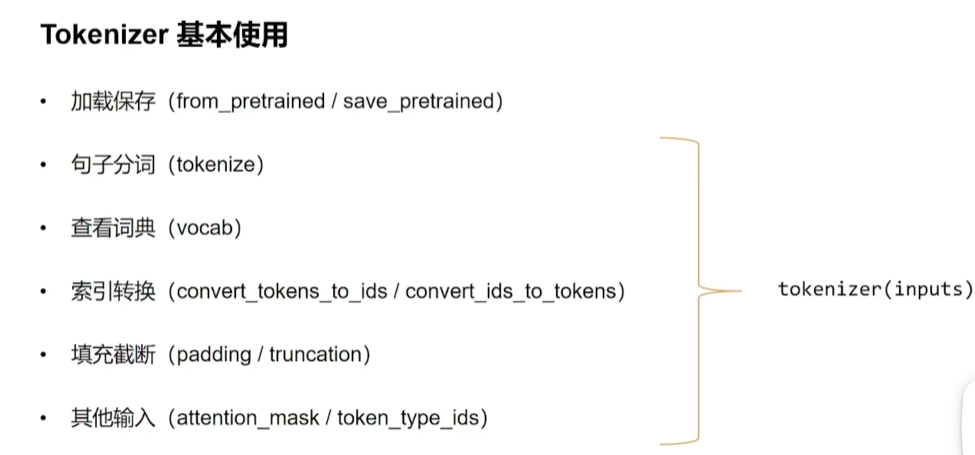

In [1]:
from transformers import AutoTokenizer

In [2]:
# 预处理的句子
sen = "我的未来不是梦"

In [3]:
# step 1 加载与保存
tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-chinese")
tokenizer


BertTokenizerFast(name_or_path='google-bert/bert-base-chinese', vocab_size=21128, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=True),  added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}

In [4]:
# tokenizer 保存到本地
tokenizer.save_pretrained("./roberta_tokenizer")

('./roberta_tokenizer\\tokenizer_config.json',
 './roberta_tokenizer\\special_tokens_map.json',
 './roberta_tokenizer\\vocab.txt',
 './roberta_tokenizer\\added_tokens.json',
 './roberta_tokenizer\\tokenizer.json')

In [5]:
# 此时就可以直接从本地加载
tokenizer = AutoTokenizer.from_pretrained("./roberta_tokenizer/")

In [6]:
tokenizer

BertTokenizerFast(name_or_path='./roberta_tokenizer/', vocab_size=21128, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=True),  added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}

In [7]:
# step2 句子分词
tokens = tokenizer.tokenize(sen)
tokens

['我', '的', '未', '来', '不', '是', '梦']

In [8]:
# step3 查看词典
tokenizer.vocab

{'52kb': 12811,
 '##峇': 15337,
 '##溥': 17038,
 '缀': 5345,
 '[unused17]': 17,
 '►': 467,
 '##役': 15571,
 '##鋅': 20137,
 '##馆': 20724,
 '垠': 1802,
 '##済': 16984,
 '螯': 6088,
 '脉': 5549,
 '##咕': 14532,
 '##潼': 17122,
 '憔': 2732,
 '##س': 13433,
 '##連': 19922,
 '抑': 2829,
 '##007': 12843,
 'leonnhurt': 13160,
 '##娜': 15082,
 '##棗': 16531,
 '##詠': 19328,
 'flickr': 11470,
 '浜': 3853,
 '疹': 4562,
 '糍': 5129,
 'polo': 10710,
 '##將': 15257,
 '嶺': 2327,
 '##顫': 20605,
 'z2': 12568,
 'fe': 12605,
 '##lmer': 12763,
 '壽': 1904,
 '罌': 5379,
 '鑾': 7149,
 '##pm': 9280,
 '##oper': 11468,
 '##霰': 20519,
 '峥': 2286,
 '觎': 6232,
 'carlo': 12628,
 '嗰': 1639,
 '窯': 4982,
 '##钾': 20242,
 '0fork': 8453,
 '巒': 2332,
 '廖': 2445,
 '詣': 6274,
 '運': 6880,
 'yu': 10825,
 '##葬': 18930,
 '##向': 14460,
 'js': 9016,
 '跟': 6656,
 '##攀': 16159,
 '12345': 9700,
 'ᗜ': 329,
 '##固': 14800,
 '##〇': 13649,
 '247': 11128,
 '5s': 9376,
 '簫': 5084,
 '潰': 4061,
 '##旻': 16258,
 '##瞟': 17797,
 'file': 9828,
 '##狀': 17368,
 '噪': 1692

In [9]:
# step4 索引转换
## token->id
ids = tokenizer.convert_tokens_to_ids(tokens)
ids

[2769, 4638, 3313, 3341, 679, 3221, 3457]

In [14]:
## id->token
tokens = tokenizer.convert_ids_to_tokens(ids)
tokens

['我', '的', '未', '来', '不', '是', '梦']

In [11]:
## token->str
str_sen = tokenizer.convert_tokens_to_string(tokens)
str_sen

'我 的 未 来 不 是 梦'

In [13]:
# 便捷的实现方式

ids = tokenizer.encode(sen, add_special_tokens="True")
## 默认True
ids

## 最前面多了个'101'(CLS) 后面多了'102'(SEP)

TypeError: argument 'add_special_tokens': 'str' object cannot be converted to 'PyBool'

In [15]:
str_sen = tokenizer.decode(ids, skip_special_tokens=True)
str_sen

'我 的 未 来 不 是 梦'

In [16]:
# step5 填充与截断
ids = tokenizer.encode(sen, padding="max_length", max_length=15)
ids
## 填充了3个0

[101, 2769, 4638, 3313, 3341, 679, 3221, 3457, 102, 0, 0, 0, 0, 0, 0]

In [17]:
ids = tokenizer.encode(sen, max_length=5, truncation=True)
ids

[101, 2769, 4638, 3313, 102]

In [18]:
# step6 其他输入部分
ids = tokenizer.encode(sen, padding="max_length", max_length=15)
ids


[101, 2769, 4638, 3313, 3341, 679, 3221, 3457, 102, 0, 0, 0, 0, 0, 0]

In [19]:
attention_mask = [1 if idx != 0 else 0 for idx in ids]
token_type_ids = [0] * len(ids)
ids, attention_mask, token_type_ids

([101, 2769, 4638, 3313, 3341, 679, 3221, 3457, 102, 0, 0, 0, 0, 0, 0],
 [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [20]:
# step7 快速调用方式
inputs = tokenizer.encode_plus(sen, padding="max_length", max_length=15)
inputs

{'input_ids': [101, 2769, 4638, 3313, 3341, 679, 3221, 3457, 102, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0]}

In [21]:
# 工程一般使用下面的代码

inputs = tokenizer(sen, padding="max_length", max_length=15)
inputs

{'input_ids': [101, 2769, 4638, 3313, 3341, 679, 3221, 3457, 102, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0]}

In [22]:
# step8 处理batch
sens = ["我的未来不是梦",
        "我认真的过每一分钟",
        "我的心跟着希望在动",]

res = tokenizer(sens)
res

{'input_ids': [[101, 2769, 4638, 3313, 3341, 679, 3221, 3457, 102], [101, 2769, 6371, 4696, 4638, 6814, 3680, 671, 1146, 7164, 102], [101, 2769, 4638, 2552, 6656, 4708, 2361, 3307, 1762, 1220, 102]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}

In [23]:
%%time
for i in range(1000):
    tokenizer(sen)

CPU times: total: 78.1 ms
Wall time: 68.9 ms


In [24]:
%%time
res = tokenizer([sen]*1000)

CPU times: total: 15.6 ms
Wall time: 47.2 ms


## Fast/Slow Tokenizer

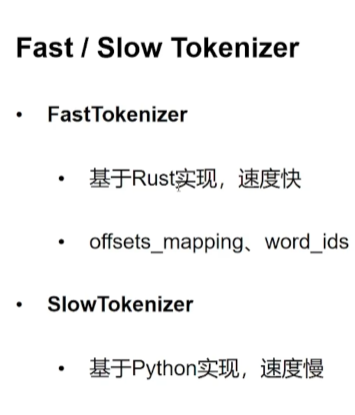

In [25]:
sen = "我的未来不是Dreaming"

In [26]:
fast_token = AutoTokenizer.from_pretrained("google-bert/bert-base-chinese")
fast_token

BertTokenizerFast(name_or_path='google-bert/bert-base-chinese', vocab_size=21128, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=True),  added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}

In [ ]:
slow_token = AutoTokenizer.from_pretrained("google-bert/bert-base-chinese", use_fast = False)
slow_token

In [27]:
inputs.word_ids()

[None, 0, 1, 2, 3, 4, 5, 6, None, None, None, None, None, None, None]

## 特殊分词器加载

In [28]:
from transformers import AutoTokenizer

In [ ]:
# 针对某些分词器是自己写的
tokenizer = AutoTokenizer.from_pretrained("THUDM/chatglm-6b",trust_remote_code = True)